# 1. Apresentação do Problema

O presente trabalho tem como objetivo investigar a possibilidade de prever a evolução do risco de deriva distópica no Brasil utilizando indicadores institucionais produzidos pelo projeto V-Dem (Varieties of Democracy).

Inspirado nos conceitos apresentados na obra *1984*, de George Orwell, foi desenvolvido um indicador sintético denominado **Distopia Score**, construído a partir de diferentes dimensões relacionadas à qualidade democrática, liberdade de expressão, Estado de Direito, participação da sociedade civil e mecanismos institucionais de controle do poder.

O problema foi formulado como uma tarefa de regressão supervisionada com componente temporal. O objetivo é prever o valor do Distopia Score para o ano seguinte utilizando informações institucionais observadas no ano corrente.

A hipótese central deste estudo é que mudanças em indicadores democráticos e institucionais possuem capacidade preditiva sobre a evolução futura do Distopia Score.

As principais limitações do estudo estão relacionadas à quantidade reduzida de observações disponíveis para o Brasil e à natureza sintética do indicador criado para esta pesquisa.

# 2. Apresentação dos Dados

Foi utilizado o dataset **V-Dem Dataset v16**, produzido pelo projeto internacional Varieties of Democracy (V-Dem).

O V-Dem é uma das maiores bases de dados sobre democracia e instituições políticas do mundo, contendo milhares de indicadores relacionados a processos eleitorais, liberdade de expressão, participação política, Estado de Direito e funcionamento institucional.

Para este estudo foram selecionados apenas os registros referentes ao Brasil no período entre 2000 e 2025.

Os indicadores utilizados foram:

| Indicador | Descrição |
|------------|------------|
| Democracia Liberal | Mede a qualidade das instituições democráticas e a proteção de direitos políticos |
| Liberdade de Expressão e Informação | Mede a liberdade da imprensa e o acesso a fontes alternativas de informação |
| Estado de Direito e Liberdades Individuais | Mede a proteção de direitos civis e garantias legais |
| Participação da Sociedade Civil | Mede a capacidade de organização e atuação da sociedade civil |
| Controle Judicial sobre o Executivo | Mede a independência e a capacidade de fiscalização do Judiciário |

Esses indicadores foram utilizados para construir o Distopia Score, variável central deste estudo.

In [1]:
# Bibliotecas principais

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

SEED = 42
np.random.seed(SEED)

# 3. Análise Exploratória Inicial

Nesta etapa, os dados são carregados, filtrados para o Brasil e analisados de forma inicial. O objetivo é compreender a estrutura da base, verificar a disponibilidade dos indicadores selecionados, identificar valores ausentes e observar o comportamento temporal das variáveis que compõem o Distopia Score.

Preparação da Base de Dados

A base original utilizada neste trabalho foi obtida a partir do projeto V-Dem (Varieties of Democracy), que disponibiliza indicadores políticos e institucionais para diversos países ao longo de diferentes períodos históricos.

Como o objetivo deste estudo é analisar exclusivamente a evolução institucional do Brasil entre 2000 e 2025, foi realizada uma etapa prévia de tratamento dos dados, na qual:

Foram selecionadas apenas as observações referentes ao Brasil;
Foram mantidos somente os anos do período analisado (2000–2025);
Foram preservadas apenas as variáveis necessárias para a construção do Distopia Score.

Dessa forma, o arquivo utilizado neste notebook corresponde a uma versão reduzida e tratada da base original, contendo apenas os registros necessários para a análise.

A base completa do projeto V-Dem permanece disponível publicamente e pode ser consultada em:

https://www.v-dem.net/data/the-v-dem-dataset/

In [2]:
# Base previamente filtrada a partir do dataset completo do V-Dem
# Contém apenas observações do Brasil entre 2000 e 2025
# e as variáveis utilizadas neste estudo

url = "https://raw.githubusercontent.com/pedrohreisrj/mvp-distopia-brasil/refs/heads/main/dataset/dados_brasil_vdem.csv"

dados = pd.read_csv(url)

print("Dimensões do dataset:", dados.shape)
dados.head()

Dimensões do dataset: (26, 6)


,year,v2x_libdem,v2x_freexp_altinf,v2xcl_rol,v2x_cspart,v2x_jucon
0,2000,0.717,0.928,0.839,0.900,0.825
1,2001,0.717,0.928,0.839,0.900,0.825
2,2002,0.721,0.929,0.847,0.900,0.825
3,2003,0.722,0.923,0.847,0.948,0.825
4,2004,0.722,0.923,0.847,0.948,0.825


In [3]:
# Seleção das variáveis

variaveis_vdem = [
    "year",
    "v2x_libdem",
    "v2x_freexp_altinf",
    "v2xcl_rol",
    "v2x_cspart",
    "v2x_jucon"
]

dados = dados[variaveis_vdem].copy()

dados.head()

,year,v2x_libdem,v2x_freexp_altinf,v2xcl_rol,v2x_cspart,v2x_jucon
0,2000,0.717,0.928,0.839,0.900,0.825
1,2001,0.717,0.928,0.839,0.900,0.825
2,2002,0.721,0.929,0.847,0.900,0.825
3,2003,0.722,0.923,0.847,0.948,0.825
4,2004,0.722,0.923,0.847,0.948,0.825


In [4]:
# Nomes amigáveis para as variáveis

nomes_variaveis = {
    "year": "Ano",
    "v2x_libdem": "Democracia Liberal",
    "v2x_freexp_altinf": "Liberdade de Expressão e Informação",
    "v2xcl_rol": "Estado de Direito e Liberdades Individuais",
    "v2x_cspart": "Participação da Sociedade Civil",
    "v2x_jucon": "Controle Judicial sobre o Executivo"
}

dados.rename(columns=nomes_variaveis).head()

,Ano,Democracia Liberal,Liberdade de Expressão e Informação,Estado de Direito e Liberdades Individuais,Participação da Sociedade Civil,Controle Judicial sobre o Executivo
0,2000,0.717,0.928,0.839,0.900,0.825
1,2001,0.717,0.928,0.839,0.900,0.825
2,2002,0.721,0.929,0.847,0.900,0.825
3,2003,0.722,0.923,0.847,0.948,0.825
4,2004,0.722,0.923,0.847,0.948,0.825


In [5]:
dados.isnull().sum()

,0
year,0
v2x_libdem,0
v2x_freexp_altinf,0
v2xcl_rol,0
v2x_cspart,0
v2x_jucon,0


A verificação de valores ausentes é importante para garantir que os indicadores selecionados possam ser utilizados na construção do Distopia Score. Como foram escolhidos índices consolidados do V-Dem para o Brasil no período recente, espera-se baixa incidência de valores ausentes nessas variáveis.

In [6]:
dados.rename(columns=nomes_variaveis).describe()

,Ano,Democracia Liberal,Liberdade de Expressão e Informação,Estado de Direito e Liberdades Individuais,Participação da Sociedade Civil,Controle Judicial sobre o Executivo
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,2012.500000,0.702346,0.878615,0.814577,0.875346,0.885231
std,7.648529,0.086794,0.083486,0.071761,0.086359,0.051932
min,2000.000000,0.528000,0.699000,0.634000,0.711000,0.806000
25%,2006.250000,0.663500,0.835500,0.826750,0.808000,0.825500
50%,2012.500000,0.721500,0.925000,0.847000,0.917000,0.917500
75%,2018.750000,0.769750,0.928750,0.856000,0.942000,0.926500
max,2025.000000,0.783000,0.934000,0.860000,0.948000,0.954000


## 3.1 Visualização dos Indicadores Institucionais

A seguir, são apresentados os cinco indicadores institucionais selecionados para compor o Distopia Score. Todos possuem escala entre 0 e 1, em que valores mais altos indicam melhores condições institucionais.

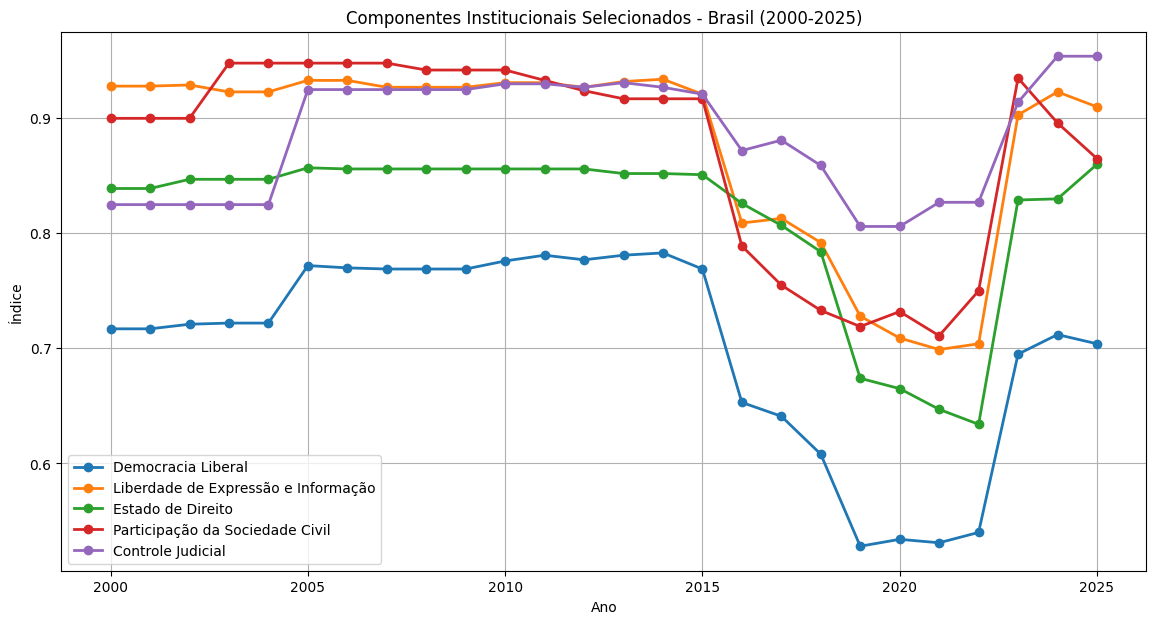

In [7]:
labels_grafico = {
    "v2x_libdem": "Democracia Liberal",
    "v2x_freexp_altinf": "Liberdade de Expressão e Informação",
    "v2xcl_rol": "Estado de Direito",
    "v2x_cspart": "Participação da Sociedade Civil",
    "v2x_jucon": "Controle Judicial"
}

plt.figure(figsize=(14, 7))

for coluna, label in labels_grafico.items():
    plt.plot(
        dados["year"],
        dados[coluna],
        marker="o",
        linewidth=2,
        label=label
    )

plt.title("Componentes Institucionais Selecionados - Brasil (2000-2025)")
plt.xlabel("Ano")
plt.ylabel("Índice")
plt.legend()
plt.grid(True)
plt.show()

O gráfico evidencia que os indicadores selecionados apresentam comportamento relativamente estável até meados da década de 2010, seguido por deterioração entre 2016 e 2022 e recuperação nos anos posteriores. Esse comportamento sugere que os indicadores escolhidos capturam mudanças institucionais relevantes ao longo do tempo.

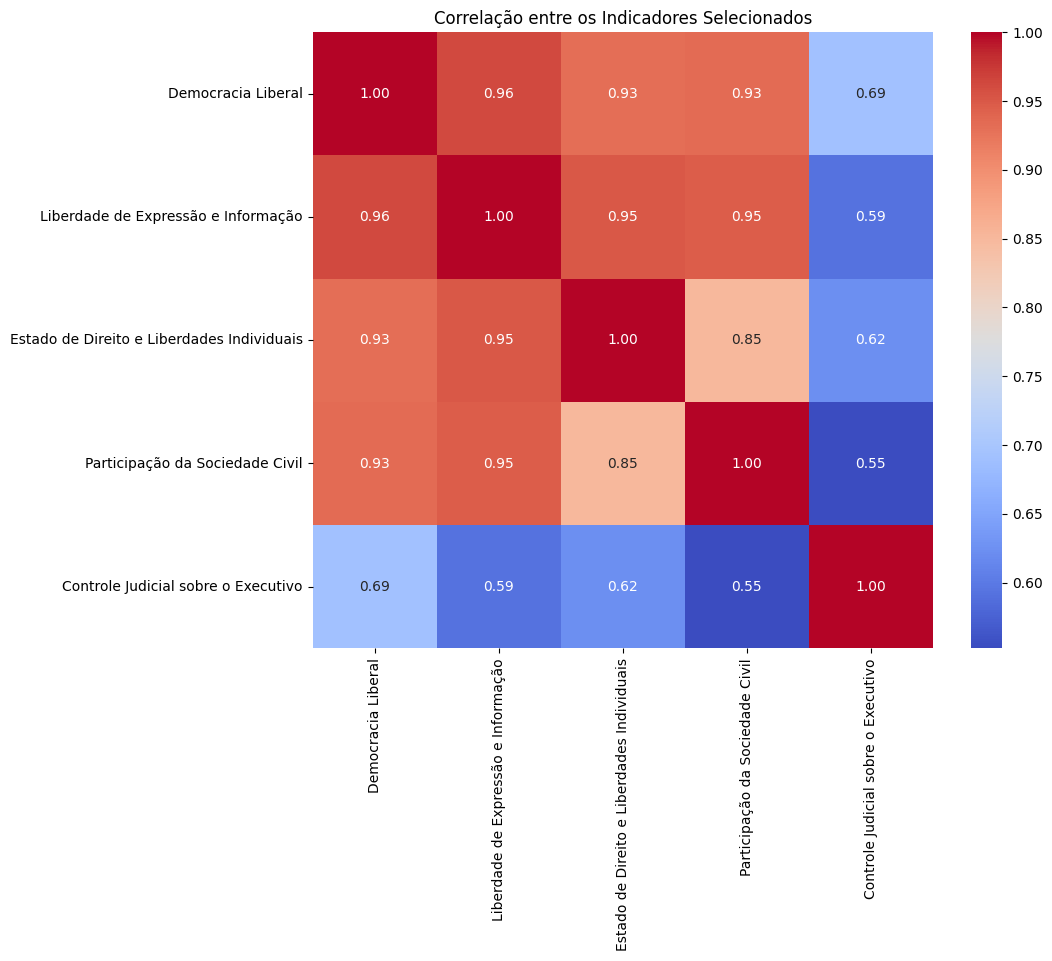

In [8]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    dados[
        [
            "v2x_libdem",
            "v2x_freexp_altinf",
            "v2xcl_rol",
            "v2x_cspart",
            "v2x_jucon"
        ]
    ].rename(columns=nomes_variaveis).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação entre os Indicadores Selecionados")
plt.show()

A matriz de correlação mostra forte associação entre a maioria dos indicadores institucionais, especialmente entre Democracia Liberal, Liberdade de Expressão e Estado de Direito. Isso indica que essas dimensões tendem a se mover de forma conjunta. O indicador de Controle Judicial sobre o Executivo apresenta correlação um pouco menor com os demais, sugerindo que ele adiciona uma dimensão complementar ao índice.

# 4. Construção do Distopia Score

O objetivo deste projeto é criar um indicador sintético denominado Distopia Score, inspirado em características observadas em regimes autoritários retratados na literatura distópica, especialmente na obra *1984* de George Orwell.

Nesse contexto, uma sociedade tende a se aproximar de um cenário distópico quando apresenta:

- Redução da democracia;
- Restrição à liberdade de expressão;
- Enfraquecimento do Estado de Direito;
- Menor participação da sociedade civil;
- Redução dos mecanismos de controle sobre o poder executivo.

Como os indicadores do V-Dem possuem interpretação positiva (valores maiores representam instituições mais fortes), foi necessário inverter essa lógica para representar risco institucional.

Dessa forma, o Distopia Score é calculado como:

Distopia Score = 1 − Média dos Indicadores Institucionais

Valores próximos de 0 representam ambientes mais democráticos e institucionalmente saudáveis.

Valores próximos de 1 representam ambientes com maior deterioração institucional e, consequentemente, maior proximidade conceitual com um cenário distópico.


In [9]:
dados["distopia_score"] = 1 - (
    dados[
        [
            "v2x_libdem",
            "v2x_freexp_altinf",
            "v2xcl_rol",
            "v2x_cspart",
            "v2x_jucon"
        ]
    ].mean(axis=1)
)

dados[
    ["year", "distopia_score"]
].head()

,year,distopia_score
0,2000,0.1582
1,2001,0.1582
2,2002,0.1556
3,2003,0.1470
4,2004,0.1470


## 4.1 Evolução Histórica do Distopia Score

Após a construção do índice, é possível observar sua evolução ao longo do período analisado.

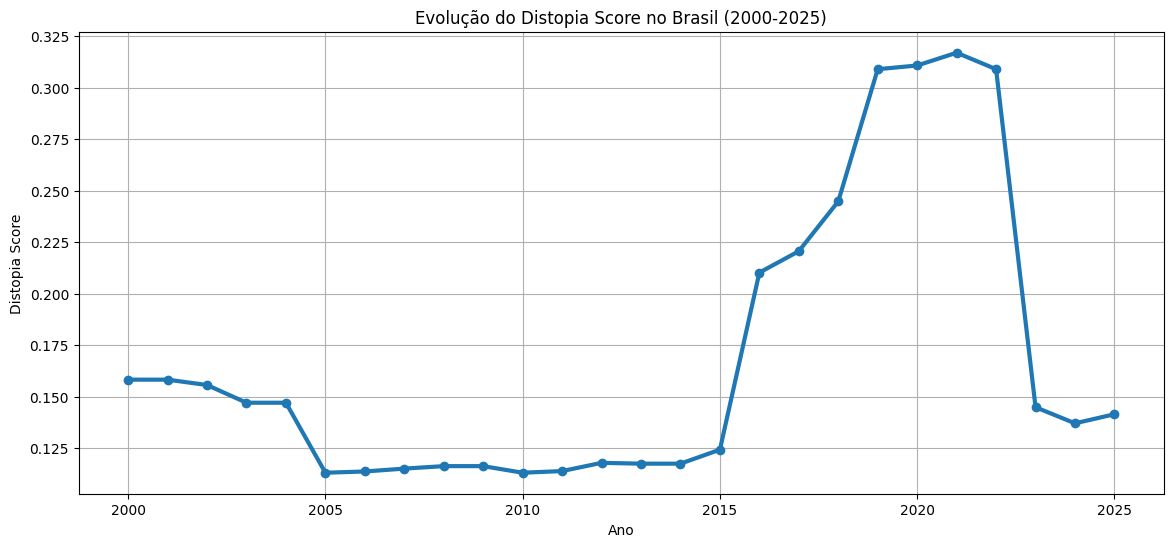

In [10]:
plt.figure(figsize=(14,6))

plt.plot(
    dados["year"],
    dados["distopia_score"],
    marker="o",
    linewidth=3
)

plt.title("Evolução do Distopia Score no Brasil (2000-2025)")
plt.xlabel("Ano")
plt.ylabel("Distopia Score")
plt.grid(True)

plt.show()

Observa-se que o Distopia Score permaneceu relativamente baixo entre 2000 e 2015, indicando estabilidade institucional.

Entre 2016 e 2022 ocorre uma elevação significativa do índice, sugerindo deterioração simultânea de diversas dimensões institucionais analisadas.

A partir de 2023 observa-se uma redução do score, indicando recuperação parcial dos indicadores utilizados na composição do índice.

É importante destacar que o Distopia Score não mede autoritarismo de forma direta, mas sim um risco institucional construído a partir da combinação dos indicadores selecionados.

In [11]:
top_distopia = (
    dados[
        ["year", "distopia_score"]
    ]
    .sort_values(
        "distopia_score",
        ascending=False
    )
    .head(10)
)

top_distopia

,year,distopia_score
21,2021,0.3170
20,2020,0.3108
19,2019,0.3090
22,2022,0.3090
18,2018,0.2448
17,2017,0.2206
16,2016,0.2102
0,2000,0.1582
1,2001,0.1582
2,2002,0.1556


# 5. Modelagem Preditiva

Após a construção do Distopia Score, o próximo objetivo consiste em verificar se os indicadores institucionais observados em determinado ano podem ser utilizados para prever o nível de risco institucional no ano seguinte.

O problema é tratado como uma tarefa de regressão supervisionada.

A variável alvo (target) corresponde ao Distopia Score do ano seguinte, enquanto as variáveis explicativas são os indicadores institucionais observados no ano atual.

In [12]:
dados["target"] = (
    dados["distopia_score"]
    .shift(-1)
)

modelo_df = dados.dropna(
    subset=["target"]
).copy()

modelo_df[
    [
        "year",
        "distopia_score",
        "target"
    ]
].tail()

,year,distopia_score,target
20,2020,0.3108,0.3170
21,2021,0.3170,0.3090
22,2022,0.3090,0.1448
23,2023,0.1448,0.1370
24,2024,0.1370,0.1414


## 5.1 Construção da Variável Alvo

Para prever o comportamento futuro do índice, foi criado um deslocamento temporal de um período.

Assim, os indicadores observados em um determinado ano são utilizados para prever o Distopia Score observado no ano seguinte.

In [13]:
features = [
    "year",
    "v2x_libdem",
    "v2x_freexp_altinf",
    "v2xcl_rol",
    "v2x_cspart",
    "v2x_jucon"
]

X = modelo_df[features]

y = modelo_df["target"]

In [14]:
train_size = int(
    len(modelo_df) * 0.8
)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Treino:", len(X_train))
print("Teste:", len(X_test))

print(
    "Último ano treino:",
    modelo_df.iloc[train_size-1]["year"]
)

print(
    "Primeiro ano teste:",
    modelo_df.iloc[train_size]["year"]
)

Treino: 20
Teste: 5
Último ano treino: 2019.0
Primeiro ano teste: 2020.0


## 5.2 Divisão Temporal dos Dados

Como se trata de uma série temporal, a divisão entre treino e teste respeita a ordem cronológica dos dados.

Os anos mais antigos são utilizados para treinamento e os anos mais recentes são reservados para avaliação do modelo.

Essa estratégia evita vazamento de informação futura para o treinamento.

## 5.3 Modelo Baseline

Antes da aplicação de algoritmos de Machine Learning, foi criado um modelo de referência (baseline).

A previsão do baseline corresponde simplesmente ao valor do Distopia Score observado no ano anterior.

Qualquer modelo desenvolvido deve apresentar desempenho superior a essa estratégia simples.

In [15]:
baseline_pred = modelo_df[
    "distopia_score"
].iloc[train_size:].values

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = (
    mean_squared_error(
        y_test,
        baseline_pred
    ) ** 0.5
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²:", baseline_r2)

MAE: 0.03811999999999995
RMSE: 0.07368077089716145
R²: 0.236144254459268


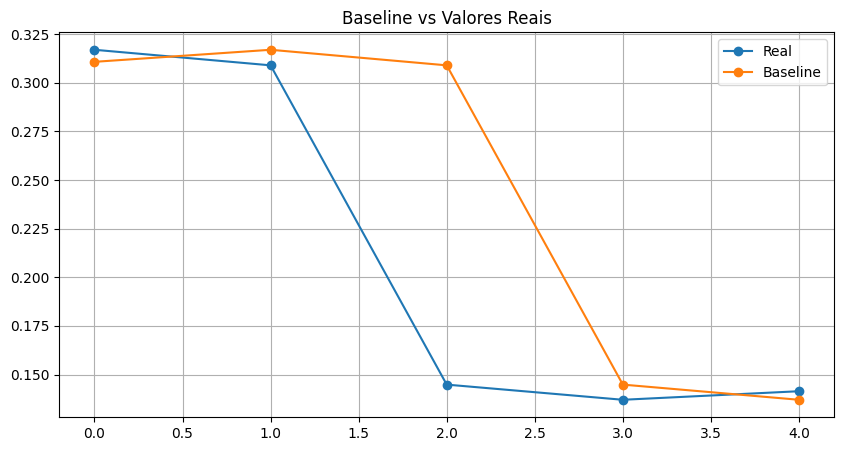

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    marker="o",
    label="Real"
)

plt.plot(
    baseline_pred,
    marker="o",
    label="Baseline"
)

plt.title("Baseline vs Valores Reais")
plt.legend()
plt.grid(True)

plt.show()

## 5.4 Regressão Linear

O primeiro modelo de Machine Learning utilizado foi a Regressão Linear.

Esse algoritmo busca identificar relações lineares entre os indicadores institucionais e o Distopia Score observado no ano seguinte.

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

In [19]:
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = (
    mean_squared_error(
        y_test,
        lr_pred
    ) ** 0.5
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

MAE: 0.12488420245457335
RMSE: 0.1451802461490334
R²: -1.9656376339792607


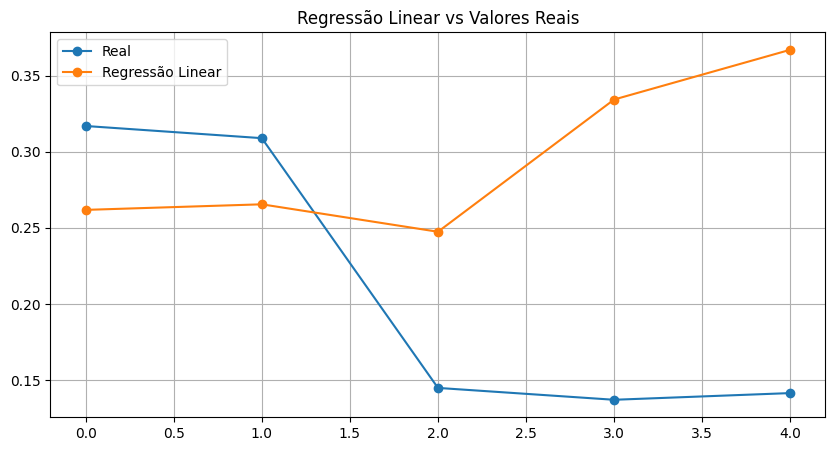

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    marker="o",
    label="Real"
)

plt.plot(
    lr_pred,
    marker="o",
    label="Regressão Linear"
)

plt.title("Regressão Linear vs Valores Reais")
plt.legend()
plt.grid(True)

plt.show()

Os resultados indicaram baixo desempenho da Regressão Linear.

Isso sugere que a relação entre os indicadores institucionais e o Distopia Score futuro não é estritamente linear, limitando a capacidade preditiva desse modelo.

## 5.5 Random Forest

O segundo algoritmo utilizado foi o Random Forest Regressor.

Esse modelo é baseado em múltiplas árvores de decisão e possui capacidade de capturar relações não lineares entre as variáveis.

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [22]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = (
    mean_squared_error(
        y_test,
        rf_pred
    ) ** 0.5
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 0.06030879999999987
RMSE: 0.08059029663675404
R²: 0.08616342494704754


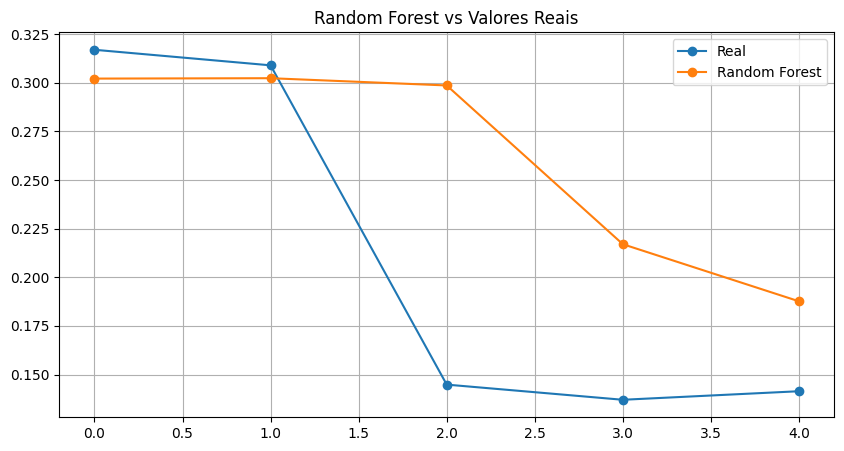

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    marker="o",
    label="Real"
)

plt.plot(
    rf_pred,
    marker="o",
    label="Random Forest"
)

plt.title("Random Forest vs Valores Reais")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
importancias = pd.DataFrame({
    "Variável": [
        "Ano",
        "Democracia Liberal",
        "Liberdade de Expressão e Informação",
        "Estado de Direito",
        "Participação da Sociedade Civil",
        "Controle Judicial sobre o Executivo"
    ],
    "Importância": rf.feature_importances_
})

importancias.sort_values(
    "Importância",
    ascending=False
)

,Variável,Importância
0,Ano,0.462898
2,Liberdade de Expressão e Informação,0.302984
1,Democracia Liberal,0.091392
4,Participação da Sociedade Civil,0.077507
3,Estado de Direito,0.037780
5,Controle Judicial sobre o Executivo,0.027438


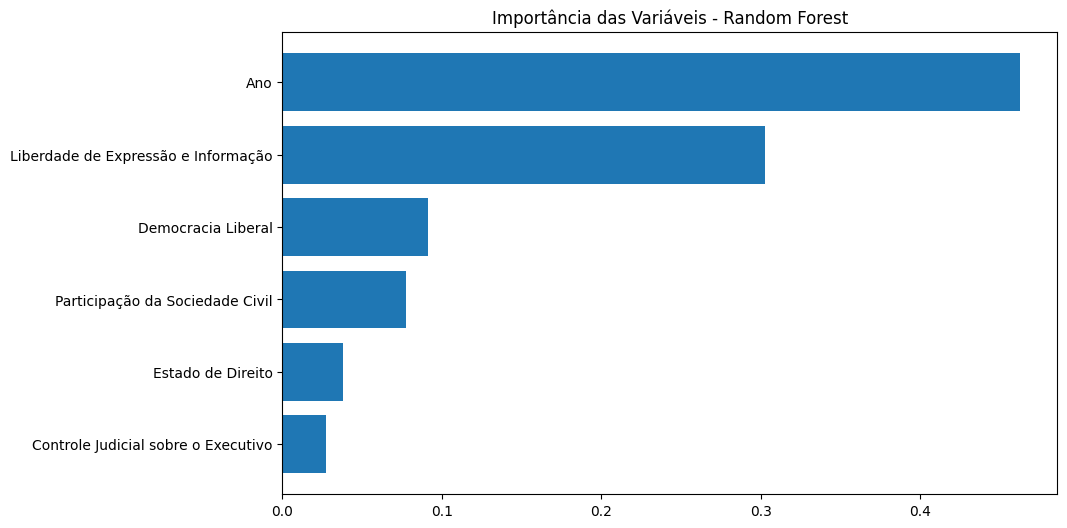

In [25]:
importancias = importancias.sort_values(
    "Importância"
)

plt.figure(figsize=(10,6))

plt.barh(
    importancias["Variável"],
    importancias["Importância"]
)

plt.title("Importância das Variáveis - Random Forest")

plt.show()

A análise de importância das variáveis permite identificar quais dimensões institucionais contribuíram mais para as previsões realizadas pelo modelo.

Os resultados sugerem que a evolução temporal e a liberdade de expressão possuem forte influência sobre o Distopia Score futuro.

## 5.6 Otimização de Hiperparâmetros

Foi realizada uma busca em grade (Grid Search) para encontrar combinações de hiperparâmetros capazes de melhorar o desempenho do modelo Random Forest.

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4, None],
    "min_samples_leaf": [1, 2, 3]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3
)

rf_grid.fit(
    X_train,
    y_train
)

print(
    "Melhores parâmetros:",
    rf_grid.best_params_
)

Melhores parâmetros: {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 200}


In [27]:
rf_tuned = rf_grid.best_estimator_

rf_tuned_pred = rf_tuned.predict(
    X_test
)

In [28]:
rf_tuned_mae = mean_absolute_error(
    y_test,
    rf_tuned_pred
)

rf_tuned_rmse = (
    mean_squared_error(
        y_test,
        rf_tuned_pred
    ) ** 0.5
)

rf_tuned_r2 = r2_score(
    y_test,
    rf_tuned_pred
)

print("MAE:", rf_tuned_mae)
print("RMSE:", rf_tuned_rmse)
print("R²:", rf_tuned_r2)

MAE: 0.05954699756132749
RMSE: 0.0779974294730161
R²: 0.14402001948930165


## 5.7 Comparação dos Modelos

Por fim, os modelos desenvolvidos foram comparados utilizando as métricas MAE, RMSE e R².

In [29]:
comparacao = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regressão Linear",
        "Random Forest",
        "Random Forest Tunado"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae,
        rf_tuned_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        rf_rmse,
        rf_tuned_rmse
    ],
    "R²": [
        baseline_r2,
        lr_r2,
        rf_r2,
        rf_tuned_r2
    ]
})

comparacao.sort_values(
    "MAE"
)

,Modelo,MAE,RMSE,R²
0,Baseline,0.038120,0.073681,0.236144
3,Random Forest Tunado,0.059547,0.077997,0.144020
2,Random Forest,0.060309,0.080590,0.086163
1,Regressão Linear,0.124884,0.145180,-1.965638


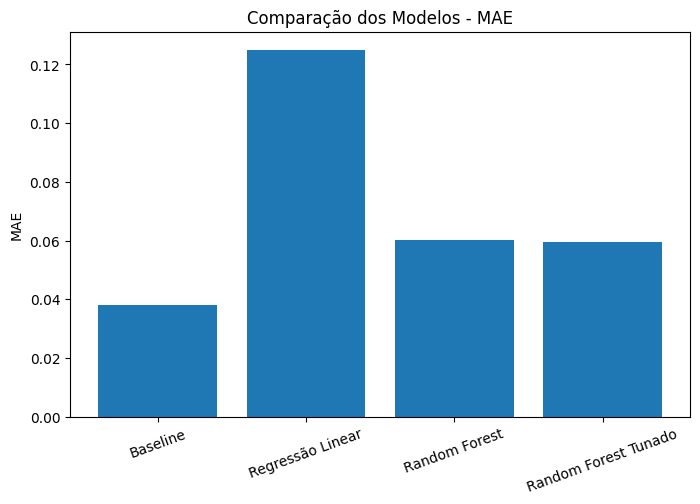

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    comparacao["Modelo"],
    comparacao["MAE"]
)

plt.title("Comparação dos Modelos - MAE")
plt.ylabel("MAE")

plt.xticks(rotation=20)

plt.show()

# 6. Conclusões

Este projeto teve como objetivo desenvolver um indicador sintético denominado Distopia Score para avaliar o risco institucional do Brasil com base em indicadores do projeto V-Dem.

Inspirado em elementos presentes em obras distópicas como *1984*, de George Orwell, o índice foi construído a partir de cinco dimensões institucionais:

- Democracia Liberal;
- Liberdade de Expressão e Informação;
- Estado de Direito e Liberdades Individuais;
- Participação da Sociedade Civil;
- Controle Judicial sobre o Executivo.

A análise exploratória demonstrou que essas dimensões apresentaram deterioração significativa entre 2016 e 2022, seguida por recuperação parcial nos anos mais recentes.

A combinação dessas variáveis permitiu construir um indicador único capaz de sintetizar mudanças institucionais ao longo do tempo.

## Resultados da Modelagem

Foram avaliadas diferentes abordagens para prever o Distopia Score do ano seguinte:

- Baseline;
- Regressão Linear;
- Random Forest;
- Random Forest com ajuste de hiperparâmetros.

Os resultados mostraram que o modelo Baseline apresentou o melhor desempenho preditivo.

Esse resultado indica que o Distopia Score possui elevada persistência temporal, ou seja, o valor observado em um determinado ano tende a ser um bom preditor do valor do ano seguinte.

Os modelos mais complexos não conseguiram superar essa estratégia simples devido principalmente ao tamanho reduzido da amostra disponível.

## Limitações

Algumas limitações devem ser consideradas na interpretação dos resultados:

1. O conjunto de dados contém apenas 26 observações anuais (2000-2025);

2. O Distopia Score é um índice construído especificamente para este projeto e não representa uma medida oficial de autoritarismo ou democracia;

3. O modelo foi aplicado apenas ao Brasil, limitando a generalização dos resultados para outros países;

4. Eventos políticos, econômicos e sociais complexos não foram modelados explicitamente.

## Trabalhos Futuros

Como possíveis extensões deste trabalho, destacam-se:

- Aplicação do Distopia Score a outros países;

- Construção de um painel comparativo internacional;

- Inclusão de indicadores econômicos e sociais;

- Utilização de modelos de séries temporais específicos, como ARIMA, Prophet ou LSTM;

- Avaliação da evolução institucional em horizontes de previsão superiores a um ano.

## Considerações Finais

Os resultados sugerem que indicadores institucionais podem ser utilizados para construir métricas sintéticas capazes de acompanhar mudanças na qualidade democrática ao longo do tempo.

Embora o Distopia Score seja uma simplificação da realidade, ele fornece uma forma intuitiva de visualizar tendências institucionais e discutir riscos democráticos de maneira quantitativa.

Além disso, o projeto demonstra a aplicação prática de técnicas de Ciência de Dados e Machine Learning em um tema interdisciplinar que combina política, história, sociologia e análise de dados.

# 7. Referências

Coppedge, M., Gerring, J., Knutsen, C. H., Lindberg, S. I., Teorell, J., Altman, D., Bernhard, M., Fish, M. S., Glynn, A., Hicken, A., Luhrmann, A., Marquardt, K. L., McMann, K., Paxton, P., Pemstein, D., Seim, B., Sigman, R., Skaaning, S.-E., Staton, J., ... Wilson, S. (2025). V-Dem Dataset Version 16. Varieties of Democracy Project.

Orwell, G. (1949). *1984*. London: Secker & Warburg.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

McKinney, W. (2010). Data Structures for Statistical Computing in Python. Proceedings of the 9th Python in Science Conference.

Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. Computing in Science & Engineering, 9(3), 90–95.

# 8. Checklist do MVP

## Definição do Problema

✅ Problema definido

✅ Objetivo do modelo definido

✅ Problema tratado como regressão supervisionada

✅ Hipóteses e limitações apresentadas

---

## Descrição dos Dados

✅ Dataset identificado e documentado

✅ Fonte dos dados informada

✅ Variáveis selecionadas justificadas

✅ Quantidade de registros apresentada

---

## Preparação dos Dados

✅ Seleção de atributos relevantes

✅ Criação do Distopia Score

✅ Criação da variável alvo

✅ Verificação de valores ausentes

✅ Preocupação com vazamento de dados

---

## Divisão dos Dados

✅ Divisão temporal realizada

✅ Separação treino/teste documentada

✅ Ordem cronológica respeitada

---

## Modelagem

✅ Baseline implementado

✅ Regressão Linear implementada

✅ Random Forest implementado

✅ Comparação entre modelos realizada

---

## Otimização

✅ Grid Search aplicado

✅ Hiperparâmetros documentados

✅ Comparação entre modelo original e otimizado realizada

---

## Avaliação

✅ MAE utilizado

✅ RMSE utilizado

✅ R² utilizado

✅ Comparação dos resultados realizada

✅ Limitações discutidas

---

## Conclusão

✅ Melhor solução identificada

✅ Limitações apresentadas

✅ Próximos passos sugeridos